In [13]:
import pandas as pd
import os
import numpy as np

# --------------------------------------------------
# Paths
# --------------------------------------------------
CURRENT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(CURRENT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
CW_DIR_PATH = os.path.join(DATA_DIR_PATH, "cw")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")

# --------------------------------------------------
# Load data
# --------------------------------------------------
iea = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_carbon_policies.csv"))
iea.shape

(1815, 11)

In [16]:
iea = iea[["iso_alpha_3", "year", "title"]]
iea.head()

,iso_alpha_3,year,title
0,MAR,2011,Law 47-09 on Energy Efficiency
1,FRA,2010,National Renewable Energy Action Plan (NREAP)
2,DEU,2010,Energy Concept
3,USA,1993,Clean Cities
4,AUS,2009,NSW Energy Savings Scheme


In [17]:
years = pd.Index(range(2002, 2023), name="year")
countries = iea["iso_alpha_3"].unique()

panel = (
    iea
    .groupby(["iso_alpha_3", "year"])
    .size()                          # count policies in each year
    .reindex(pd.MultiIndex.from_product([countries, years],
                                        names=["iso_alpha_3","year"]),
             fill_value=0)
    .groupby(level="iso_alpha_3")
    .cumsum()                        # <-- this creates your STOCK
    .reset_index(name="policy_stock")
)
panel

,iso_alpha_3,year,policy_stock
0,MAR,2002,0
1,MAR,2003,0
2,MAR,2004,0
3,MAR,2005,0
4,MAR,2006,1
...,...,...,...
3796,RWA,2018,1
3797,RWA,2019,2
3798,RWA,2020,2
3799,RWA,2021,2


In [18]:
import matplotlib.pyplot as plt

def plot_policy_stocks(policy_df, iso3):
    """
    Plot policy stock time series for a given ISO3 country code.

    Parameters
    ----------
    policy_df : pd.DataFrame
        DataFrame containing policy stock variables with columns:
        - iso_alpha_3
        - year
        - policy_flow_raw_stock
        - policy_flow_jur_stock
        - policy_flow_jur_nlp_stock

    iso3 : str
        ISO alpha-3 country code (e.g. 'DEU', 'MEX', 'USA')
    """

    df = (
        policy_df[policy_df["iso_alpha_3"] == iso3]
        .sort_values("year")
    )

    if df.empty:
        raise ValueError(f"No data found for ISO3 code: {iso3}")

    plt.figure(figsize=(10, 6))

    plt.plot(
        df["year"],
        df["policy_stock"],
        label="Raw policy stock",
        linewidth=2
    )

    plt.xlabel("Year")
    plt.ylabel("Policy stock (cumulative)")
    plt.title(f"Climate policy stock over time – {iso3}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


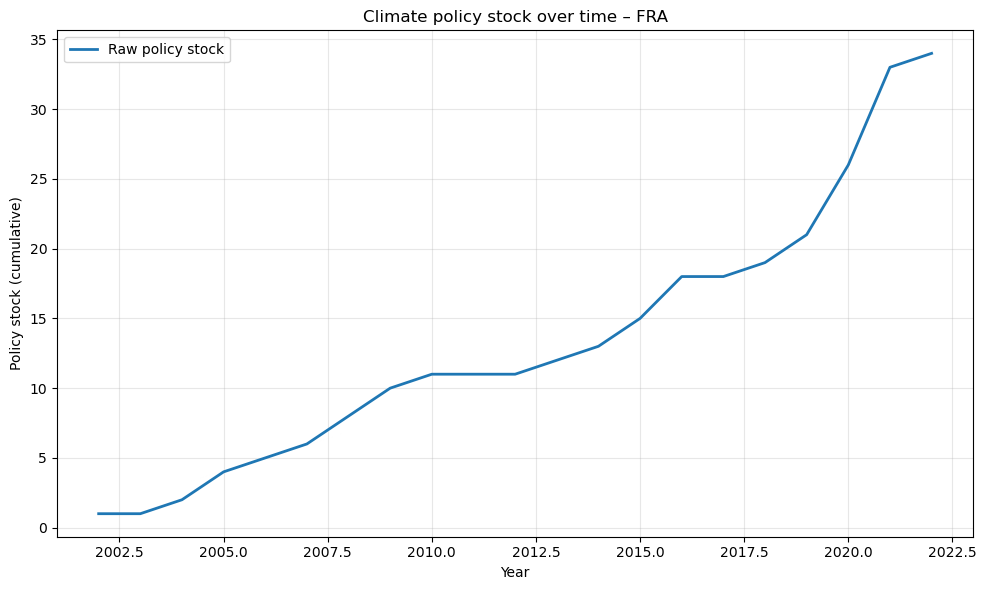

In [23]:
plot_policy_stocks(panel, "FRA")

In [24]:
panel.to_csv(
    os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_carbon_policy_stock.csv"),
    index=False
)